In [26]:
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

DATA_DIR = Path("../data")

LFW_DIR = DATA_DIR / "lfw" / "lfw-deepfunneled"
CELEBA_DIR = DATA_DIR / "CelebA"

assert LFW_DIR.exists(), f"找不到 LFW：{LFW_DIR}"
assert CELEBA_DIR.exists(), f"找不到 CelebA：{CELEBA_DIR}"

## LFW 数据分析

In [27]:
person_dirs = sorted(path for path in LFW_DIR.iterdir() if path.is_dir())

lfw_counts = pd.Series(
    {
        person_dir.name: len(list(person_dir.glob("*.jpg")))
        for person_dir in person_dirs
    },
    name="images"
)

print("图片总数：", int(lfw_counts.sum()))
print("身份数量：", len(lfw_counts))
print("只有一张图片的身份数：", int((lfw_counts == 1).sum()))

lfw_counts.describe()

图片总数： 13233
身份数量： 5749
只有一张图片的身份数： 4069


count    5749.000000
mean        2.301792
std         9.016410
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       530.000000
Name: images, dtype: float64

### 身份图片数量分布

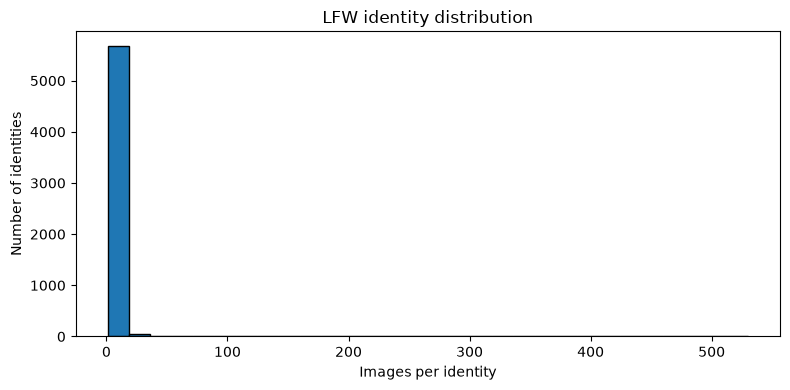

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(lfw_counts, bins=30, edgecolor="black")
plt.xlabel("Images per identity")
plt.ylabel("Number of identities")
plt.title("LFW identity distribution")
plt.tight_layout()
plt.show()

### 图片最多的身份

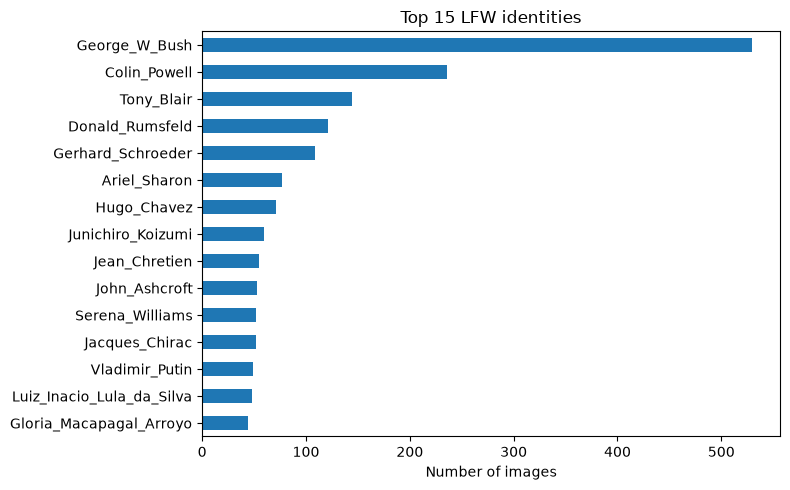

In [29]:
lfw_counts.nlargest(15).sort_values().plot(
    kind="barh",
    figsize=(8, 5),
    title="Top 15 LFW identities"
)

plt.xlabel("Number of images")
plt.tight_layout()
plt.show()

### 随机样本可视化

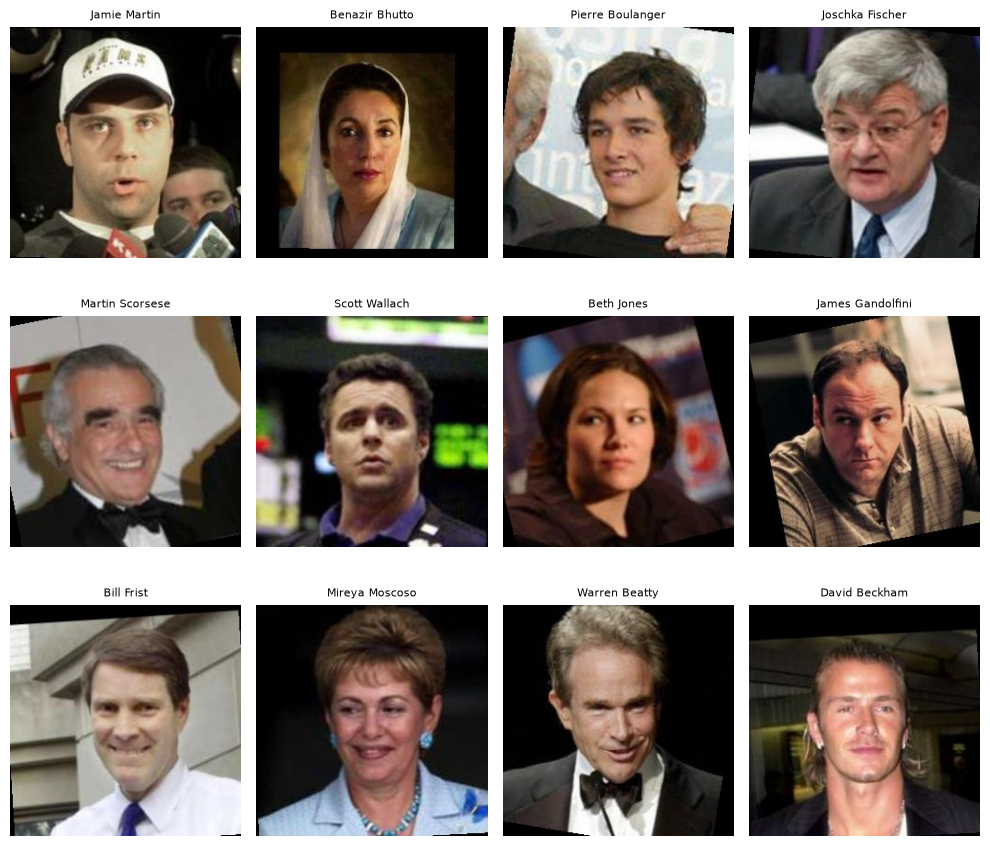

In [30]:
all_lfw_images = sorted(LFW_DIR.glob("*/*.jpg"))

rng = np.random.default_rng(42)
sample_indices = rng.choice(len(all_lfw_images), size=12, replace=False)
sample_paths = [all_lfw_images[index] for index in sample_indices]

fig, axes = plt.subplots(3, 4, figsize=(10, 9))

for axis, image_path in zip(axes.flat, sample_paths):
    image_bgr = cv2.imread(str(image_path))
    assert image_bgr is not None, f"无法读取图片：{image_path}"
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    axis.imshow(image_rgb)
    axis.set_title(image_path.parent.name.replace("_", " "), fontsize=8)
    axis.axis("off")

plt.tight_layout()
plt.show()

### 图片尺寸检查

In [31]:
image_sizes = Counter(
    Image.open(image_path).size
    for image_path in all_lfw_images
)

print("常见图片尺寸：", image_sizes.most_common(5))

常见图片尺寸： [((250, 250), 13233)]


## CelebA 属性分析

### 读取属性文件

In [32]:
attribute_path = CELEBA_DIR / "list_attr_celeba.csv"

attributes = pd.read_csv(attribute_path)
attribute_names = attributes.columns.drop("image_id").tolist()
assert len(attribute_names) == 40, "CelebA 应包含 40 个属性"

print("图片数量：", len(attributes))
print("属性数量：", len(attribute_names))

attributes.head()

图片数量： 202599
属性数量： 40


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
3,000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
4,000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


### 属性正样本比例

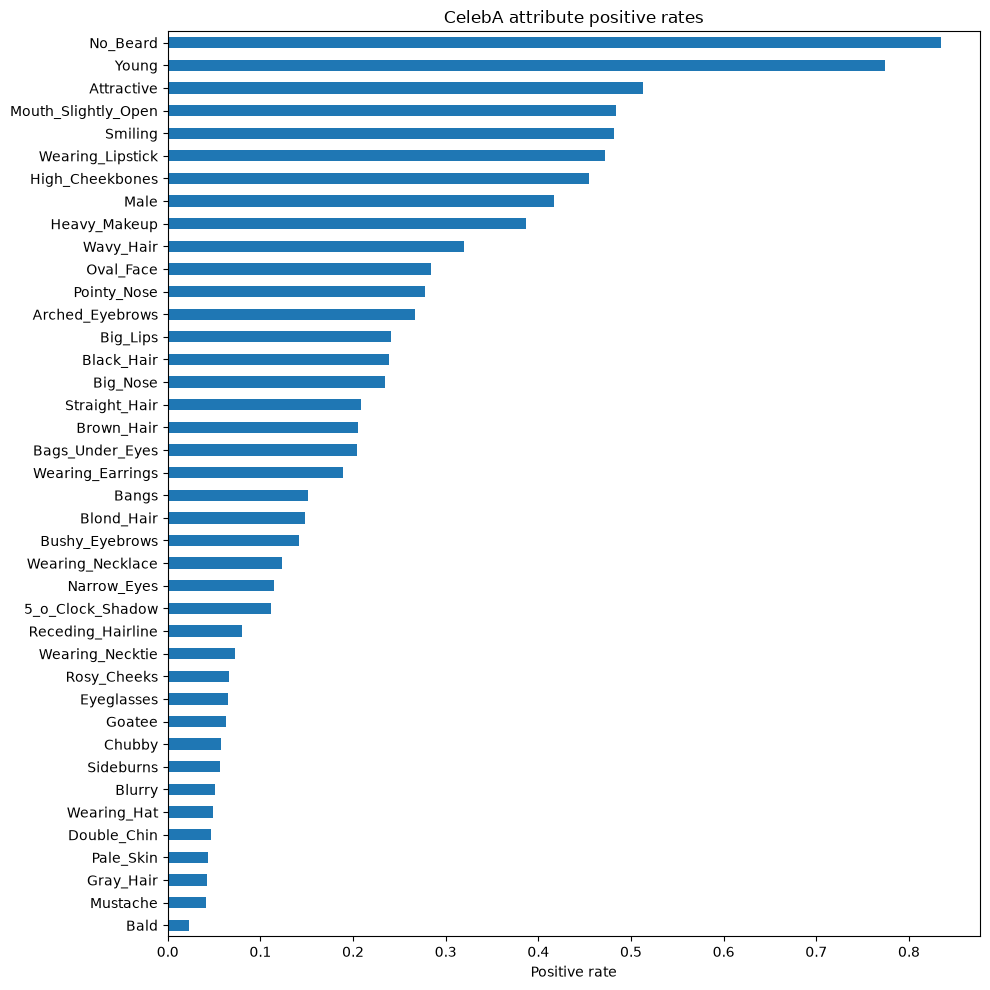

In [33]:
attribute_rates = (
    attributes[attribute_names]
    .eq(1)
    .mean()
    .sort_values()
)

attribute_rates.plot(
    kind="barh",
    figsize=(10, 10),
    title="CelebA attribute positive rates"
)

plt.xlabel("Positive rate")
plt.tight_layout()
plt.show()

### 身份分布

In [34]:
identity_data = pd.read_csv(
    CELEBA_DIR / "identity_CelebA.txt",
    sep=r"\s+",
    names=["image_id", "identity"]
)

identity_counts = identity_data["identity"].value_counts()

print("身份数量：", identity_data["identity"].nunique())
print("平均每个身份的图片数：", identity_counts.mean())
print("最少图片数：", identity_counts.min())
print("最多图片数：", identity_counts.max())

identity_counts.describe()

身份数量： 10177
平均每个身份的图片数： 19.907536602142084
最少图片数： 1
最多图片数： 35


count    10177.000000
mean        19.907537
std          8.925916
min          1.000000
25%         13.000000
50%         21.000000
75%         29.000000
max         35.000000
Name: count, dtype: float64

### 训练、验证和测试集数量

In [35]:
partition_data = pd.read_csv(CELEBA_DIR / "list_eval_partition.csv")

partition_names = {
    0: "train",
    1: "validation",
    2: "test",
}

partition_counts = (
    partition_data["partition"]
    .map(partition_names)
    .value_counts()
    .reindex(partition_names.values())
)

assert partition_counts.sum() == len(partition_data)

partition_counts

partition
train         162770
validation     19867
test           19962
Name: count, dtype: int64

### 关键点标注检查

In [36]:
landmarks = pd.read_csv(
    CELEBA_DIR / "list_landmarks_align_celeba.csv"
)

assert landmarks.shape[1] == 11  # image_id + 5 个关键点的 x/y 坐标

print("标注数量：", len(landmarks))
landmarks.head()

标注数量： 202599


,image_id,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
0,000001.jpg,69,109,106,113,77,142,73,152,108,154
1,000002.jpg,69,110,107,112,81,135,70,151,108,153
2,000003.jpg,76,112,104,106,108,128,74,156,98,158
3,000004.jpg,72,113,108,108,101,138,71,155,101,151
4,000005.jpg,66,114,112,112,86,119,71,147,104,150


## 最终对比表

In [37]:
summary = pd.DataFrame(
    {
        "Dataset": ["LFW", "CelebA"],
        "Images": [
            int(lfw_counts.sum()),
            len(attributes),
        ],
        "Identities": [
            len(lfw_counts),
            identity_data["identity"].nunique(),
        ],
        "Main annotations": [
            "Identity",
            "Identity, 40 attributes, 5 landmarks, split",
        ],
        "Main purpose": [
            "Face verification",
            "Attributes, recognition, landmarks",
        ],
    }
)

summary

,Dataset,Images,Identities,Main annotations,Main purpose
0,LFW,13233,5749,Identity,Face verification
1,CelebA,202599,10177,"Identity, 40 attributes, 5 landmarks, split","Attributes, recognition, landmarks"
